<a href="https://colab.research.google.com/github/thesamokoosi/CodVeda-Data-Analytics-Internship/blob/main/Level1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Level 1 (Basic)

**Tasks Completed:** Task 1 (Data Cleaning & Preprocessing) & Task 2 (Exploratory Data Analysis)  

## Introduction
In this notebook, we will perform Data Cleaning, Preprocessing, and Exploratory Data Analysis (EDA) on the classic Iris dataset to fulfill the Level 1 requirements of the Codveda Data Analytics Internship.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for all visualizations
sns.set_theme(style="whitegrid")

---
## Task 1: Data Cleaning and Preprocessing

### 1. Loading the Dataset
First, we will load the raw dataset using `pandas` and inspect the first few rows to understand its structure.

In [3]:
# Load the dataset
df = pd.read_csv('iris.csv')

# Display the first 5 rows
print("--- Initial Data Overview ---")
display(df.head())

--- Initial Data Overview ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 2. Handling Missing Values, Duplicates, and Formatting
To ensure data quality, we will:
1. Check for and handle any missing values (imputing numerical columns with the mean).
2. Identify and remove any duplicate rows.
3. Standardize the format of the categorical variable (`species`) to Title Case for consistency.

In [4]:
# 1. Identify and handle missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())

# Impute hypothetical missing numerical values with the mean of that column
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# 2. Remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates successfully removed.")

# 3. Standardize inconsistent data formats
# Capitalizing the species names (e.g., 'setosa' -> 'Setosa')
df['species'] = df['species'].str.title()
print("\nUnique species after standardizing formats:")
print(df['species'].unique())

--- Missing Values Check ---
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Number of duplicate rows found: 3
Duplicates successfully removed.

Unique species after standardizing formats:
['Setosa' 'Versicolor' 'Virginica']


---
## Task 2: Exploratory Data Analysis (EDA)

### 1. Summary Statistics
We will calculate key summary statistics (mean, median, standard deviation, and mode) to understand the central tendency and dispersion of our numerical features.

In [5]:
print("--- Summary Statistics ---")
display(df.describe())

print("\n--- Mode of the dataset ---")
# Calculating mode and selecting the first row (in case of multiple modes)
display(df.mode().iloc[0])

--- Summary Statistics ---


,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



--- Mode of the dataset ---


,0
sepal_length,5.0
sepal_width,3.0
petal_length,1.4
petal_width,0.2
species,Versicolor


### 2. Visualizing Data Distributions
Visualizing the data helps identify patterns, skews, and outliers.
*   **Histogram:** To view the distribution of Sepal Length.
*   **Boxplot:** To compare the distribution of Petal Length across different species.

/tmp/ipykernel_519/1949752836.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_length', data=df, palette='Set2')


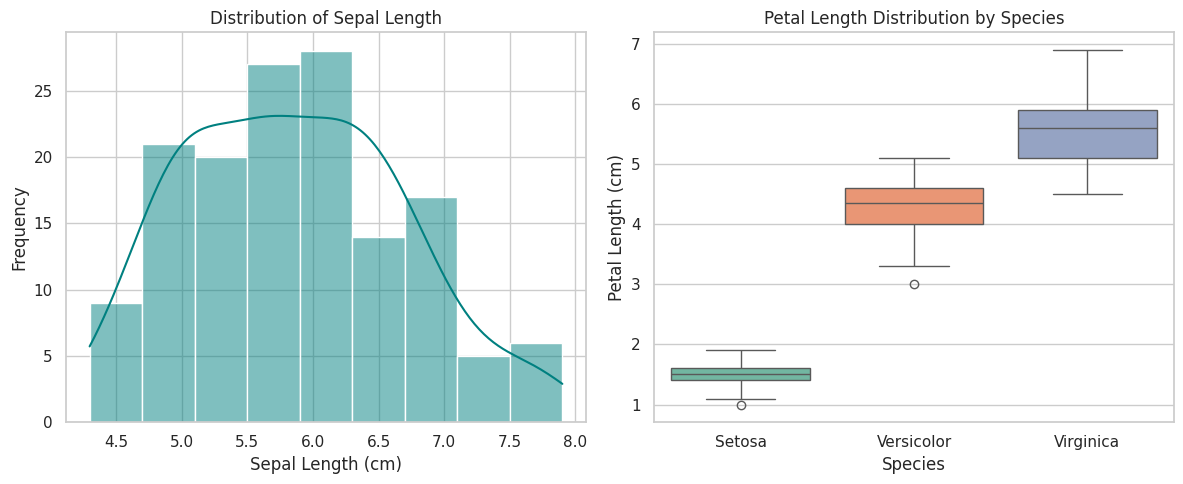

In [6]:
plt.figure(figsize=(12, 5))

# Histogram for Sepal Length
plt.subplot(1, 2, 1)
sns.histplot(df['sepal_length'], kde=True, color='teal')
plt.title('Distribution of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')

# Boxplot for Petal Length by Species
plt.subplot(1, 2, 2)
sns.boxplot(x='species', y='petal_length', data=df, palette='Set2')
plt.title('Petal Length Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')

plt.tight_layout()
plt.show()

### 3. Correlation Analysis & Feature Relationships
We will find the correlations between our numerical features to see how strongly they are related to one another. We will visualize this using a **Heatmap**, and then use a **Scatter Plot** to visualize the relationship between Sepal Length and Petal Length.

*(Note: The heatmap is exported as an image file to fulfill the reporting requirement).*

--- Correlation Matrix ---


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000



Heatmap successfully saved as 'iris_correlation_heatmap.png'!


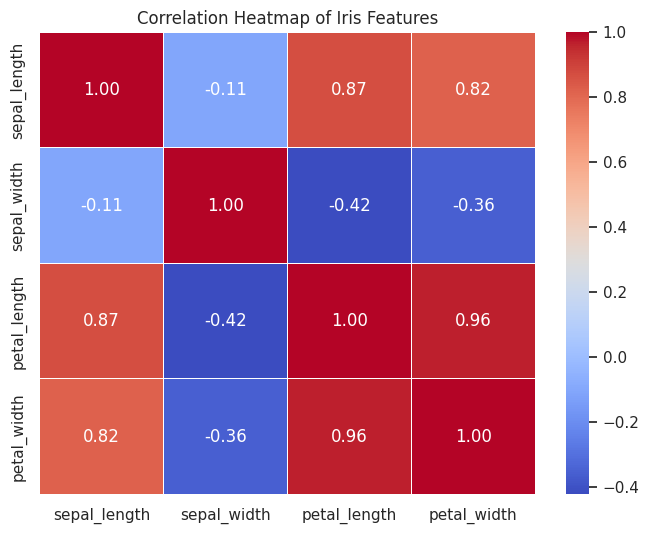

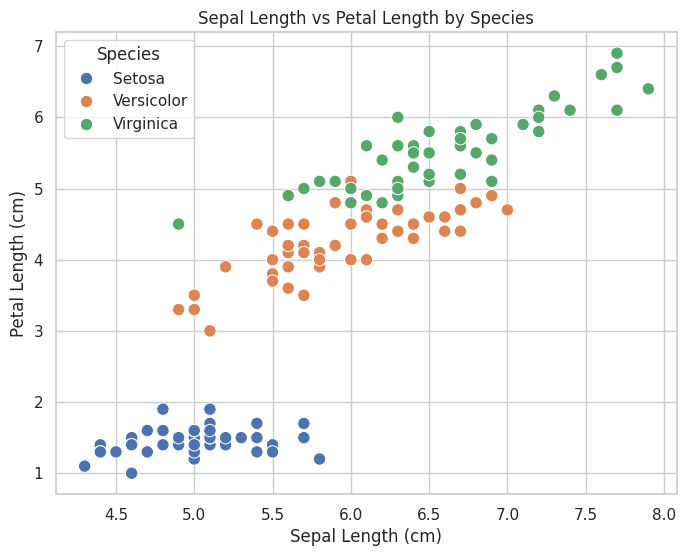

In [7]:
# Calculate Correlation Matrix
print("--- Correlation Matrix ---")
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
display(correlation_matrix)

# Visualize with a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Iris Features')

# Export plot as an image
plt.savefig('iris_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\nHeatmap successfully saved as 'iris_correlation_heatmap.png'!")
plt.show()

# Scatter plot showing relationships
plt.figure(figsize=(8, 6))
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=df, palette='deep', s=80)
plt.title('Sepal Length vs Petal Length by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Species')
plt.show()